In [6]:
# for colab
try:
    import google.colab

    !curl -LsSf https://astral.sh/uv/install.sh | sh
    !git clone https://github.com/stanfish06/micropattern.git /tmp/micropattern
    !cp -r /tmp/micropattern/. .
    !rm -rf /tmp/micropattern
    !pip install -e .
    import sys

    sys.path.insert(0, "/content/src")

    # remember to upload aws credentials
    !mkdir -p ~/.aws
    !cp /content/credentials ~/.aws
    !ls ~/.aws
except ImportError:
    raise RuntimeError(
        "make sure to connect to colab kernel or code above will wipe locally"
    )

downloading uv 0.10.2 x86_64-unknown-linux-gnu
no checksums to verify
installing to /usr/local/bin
  uv
  uvx
everything's installed!
Cloning into '/tmp/micropattern'...
remote: Enumerating objects: 112, done.
remote: Counting objects: 100% (112/112), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 112 (delta 62), reused 84 (delta 34), pack-reused 0 (from 0)
Receiving objects: 100% (112/112), 1.63 MiB | 24.56 MiB/s, done.
Resolving deltas: 100% (62/62), done.
Obtaining file:///content
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for micropattern (pyproject.toml) ... done
  Created wheel for micropattern: filename=micropattern-0.1.0-py3-none-any.whl size=1318 sha256=083f07a29993386c8aa028aca2743cd8b6155efec49804235d2c35d2b7c0a8c0
  Stored in directory: /tmp/pip-ephem-wheel-cache-tcckywn

In [7]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:           167Gi       1.5Gi       159Gi       1.0Mi       6.0Gi       164Gi
Swap:             0B          0B          0B


In [8]:
!nvidia-smi

Fri Feb 13 02:49:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   32C    P0             51W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [9]:
import micropattern as mic
from pathlib import Path
import scprep
import scanpy as sc
import numpy as np
import pandas as pd

cwd = Path(".").resolve()
print(cwd)

/content


# Data download and prep

In [8]:
mic.io.fetch_minn(cwd)

100%|██████████| 1/1 [00:00<00:00, 13.07it/s]


100%|██████████| 1/1 [00:00<00:00,  6.68it/s]


100%|██████████| 1/1 [00:00<00:00,  1.58it/s]


100%|██████████| 1/1 [00:00<00:00, 16.83it/s]


100%|██████████| 1/1 [00:00<00:00, 16.50it/s]


...

100%|██████████| 1/1 [00:00<00:00,  1.06it/s]


100%|██████████| 1/1 [00:00<00:00, 13.25it/s]


100%|██████████| 1/1 [00:00<00:00, 16.39it/s]


100%|██████████| 1/1 [00:01<00:00,  1.62s/it]


100%|██████████| 1/1 [00:00<00:00, 14.22it/s]


In [4]:
sample_list = []
for f in (cwd / "minn_data").glob("*.matrix.tsv.gz"):
    if f.is_file():
        sample_list.append(f.name.split(".")[0])
sample_list = list(set(sample_list))
sample_list.sort()
sample_list

['GSM5176718_gastruloid_0h_1',
 'GSM5176719_gastruloid_0h_2',
 'GSM5176720_gastruloid_12h_1',
 'GSM5176721_gastruloid_12h_2',
 'GSM5176722_gastruloid_24h_1',
 'GSM5176723_gastruloid_24h_2']

In [5]:
import pandas as pd
data_path = cwd / "minn_data"
data_list = {}
for s in sample_list:
    print(s)
    dat = scprep.io.load_mtx(
        data_path / f"{s}.matrix.tsv.gz",
        cell_axis="column",
        gene_names=str(data_path / f"{s}.genes.tsv.gz"),
        cell_names=str(data_path / f"{s}.barcodes.tsv.gz"),
        sparse=True,
    )
    dat.columns = dat.columns.str.replace("\t", " ")
    dat.columns = dat.columns.str.replace(" Gene Expression", "")
    dat.columns = pd.Index([g if len(g) == 1 else f"{g[1]} ({g[0]})" for g in dat.columns.str.split(" ")])
    data_list[s] = dat

GSM5176718_gastruloid_0h_1
GSM5176719_gastruloid_0h_2
GSM5176720_gastruloid_12h_1
GSM5176721_gastruloid_12h_2
GSM5176722_gastruloid_24h_1
GSM5176723_gastruloid_24h_2


# QC

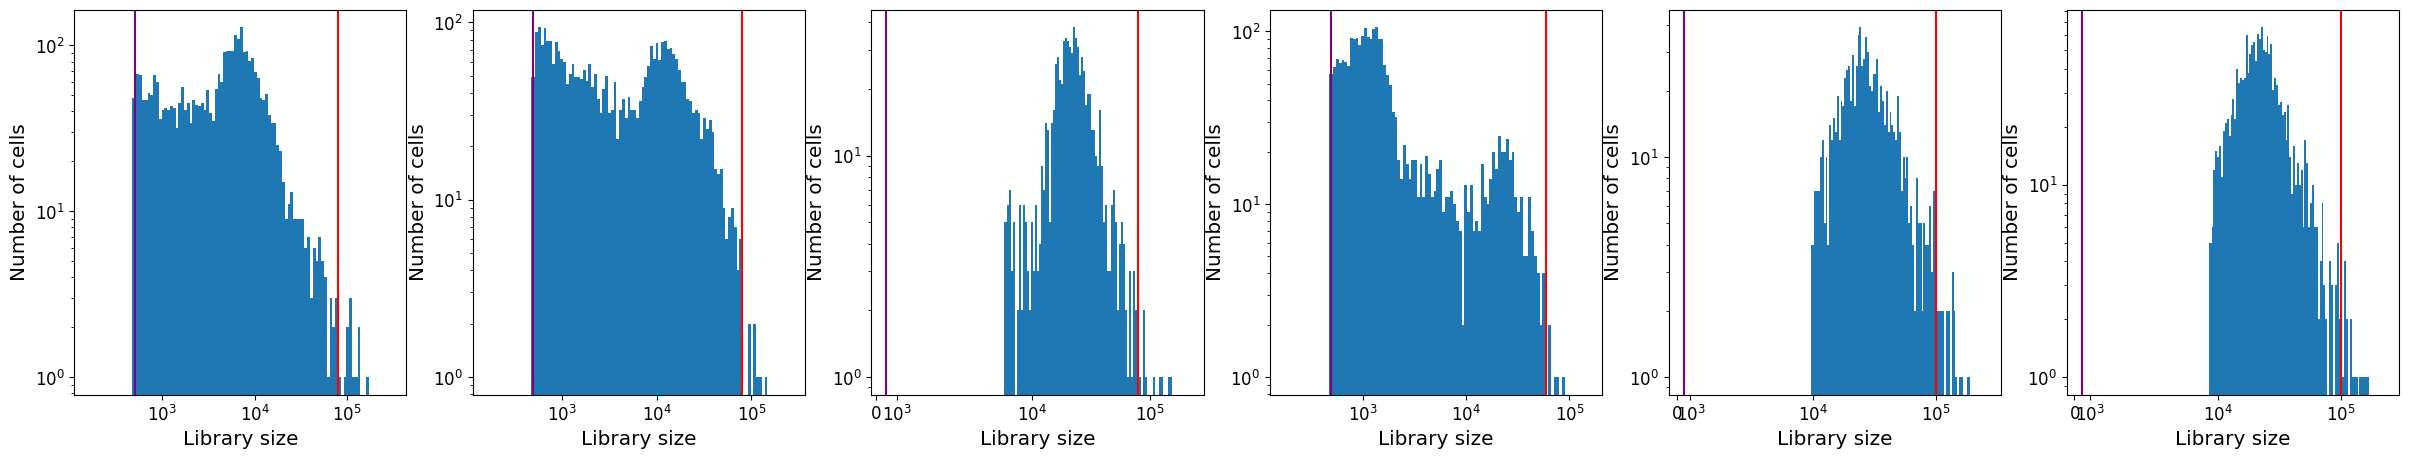

In [6]:
import matplotlib.pyplot as plt

_, axes = plt.subplots(1, len(data_list), figsize=(5 * len(data_list), 5))
thresholds = [
    (500, 8e4),
    (500, 8e4),
    (500, 8e4),
    (500, 6e4),
    (500, 1e5),
    (500, 1e5),
]
for (s, dat), (ax, th) in zip(data_list.items(), zip(axes, thresholds)):
    scprep.plot.plot_library_size(dat, ax=ax)
    ax.axvline(th[1], color='red')
    ax.axvline(th[0], color='purple')

before lib filtGSM5176718_gastruloid_0h_1: (3183, 32738)
after lib filt GSM5176718_gastruloid_0h_1: (3169, 32738)
after gene filt GSM5176718_gastruloid_0h_1: (3169, 16383)
before lib filtGSM5176719_gastruloid_0h_2: (3381, 32738)
after lib filt GSM5176719_gastruloid_0h_2: (3373, 32738)
after gene filt GSM5176719_gastruloid_0h_2: (3373, 17785)
before lib filtGSM5176720_gastruloid_12h_1: (784, 33694)
after lib filt GSM5176720_gastruloid_12h_1: (774, 33694)
after gene filt GSM5176720_gastruloid_12h_1: (774, 15087)
before lib filtGSM5176721_gastruloid_12h_2: (2492, 32738)
after lib filt GSM5176721_gastruloid_12h_2: (2484, 32738)
after gene filt GSM5176721_gastruloid_12h_2: (2484, 14852)
before lib filtGSM5176722_gastruloid_24h_1: (975, 33694)
after lib filt GSM5176722_gastruloid_24h_1: (951, 33694)
after gene filt GSM5176722_gastruloid_24h_1: (951, 15548)
before lib filtGSM5176723_gastruloid_24h_2: (1608, 33694)
after lib filt GSM5176723_gastruloid_24h_2: (1590, 33694)
after gene filt GSM51

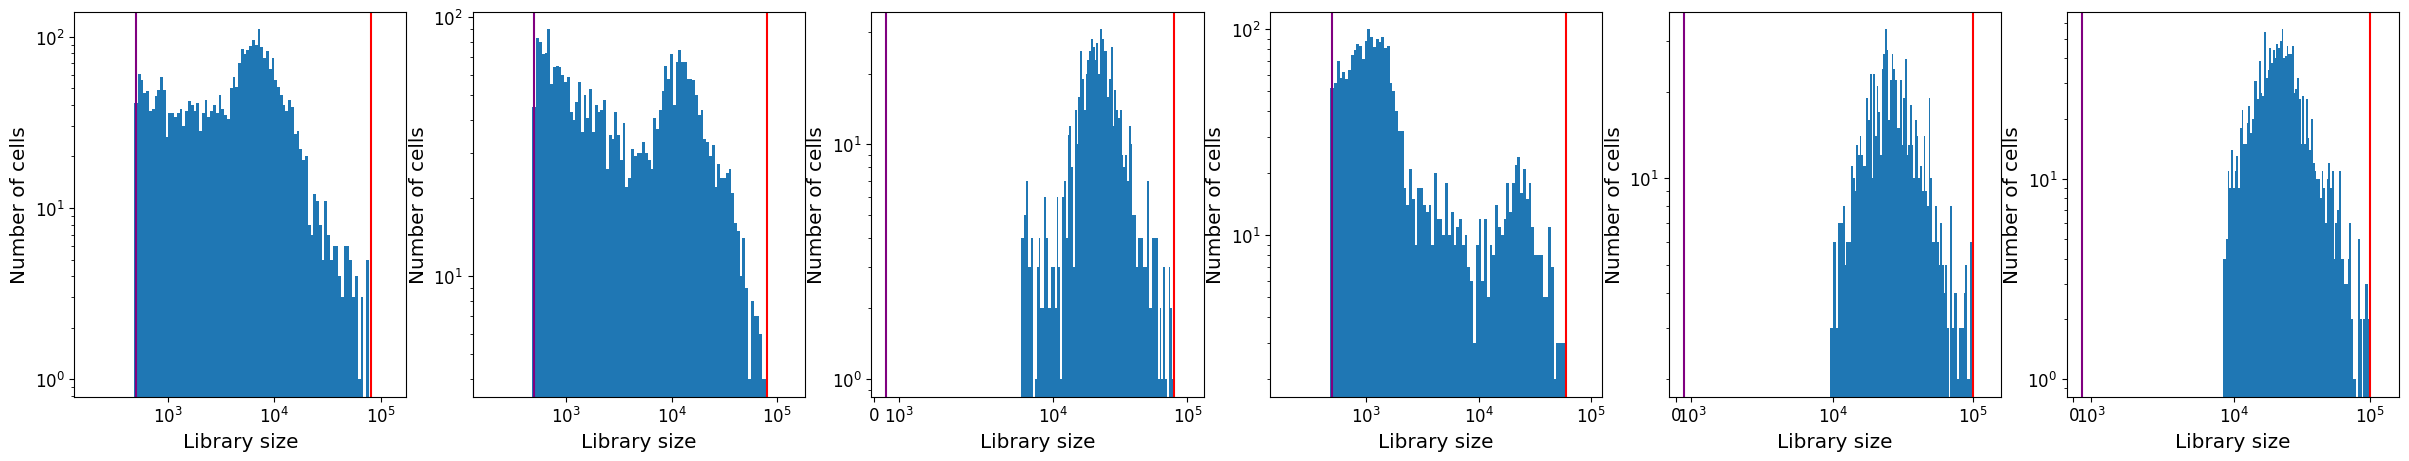

In [7]:
data_list_filt = {}
for (s, dat), th in zip(data_list.items(), thresholds):
    print(f"before lib filt{s}: {dat.shape}")
    dat = scprep.filter.filter_library_size(data=dat, cutoff=th)
    print(f"after lib filt {s}: {dat.shape}")
    dat = scprep.filter.remove_rare_genes(dat, cutoff=0, min_cells=5)
    print(f"after gene filt {s}: {dat.shape}")
    data_list_filt[s] = dat

_, axes = plt.subplots(1, len(data_list_filt), figsize=(5 * len(data_list_filt), 5))
for (s, dat), (ax, th) in zip(data_list_filt.items(), zip(axes, thresholds)):
    scprep.plot.plot_library_size(dat, ax=ax)
    ax.axvline(th[1], color='red')
    ax.axvline(th[0], color='purple')

before mito filtGSM5176718_gastruloid_0h_1: (3169, 16383)
after mito filt GSM5176718_gastruloid_0h_1: (3041, 16383)
before mito filtGSM5176719_gastruloid_0h_2: (3373, 17785)
after mito filt GSM5176719_gastruloid_0h_2: (3238, 17785)
before mito filtGSM5176720_gastruloid_12h_1: (774, 15087)
after mito filt GSM5176720_gastruloid_12h_1: (743, 15087)
before mito filtGSM5176721_gastruloid_12h_2: (2484, 14852)
after mito filt GSM5176721_gastruloid_12h_2: (2384, 14852)
before mito filtGSM5176722_gastruloid_24h_1: (951, 15548)
after mito filt GSM5176722_gastruloid_24h_1: (912, 15548)
before mito filtGSM5176723_gastruloid_24h_2: (1590, 16147)
after mito filt GSM5176723_gastruloid_24h_2: (1526, 16147)


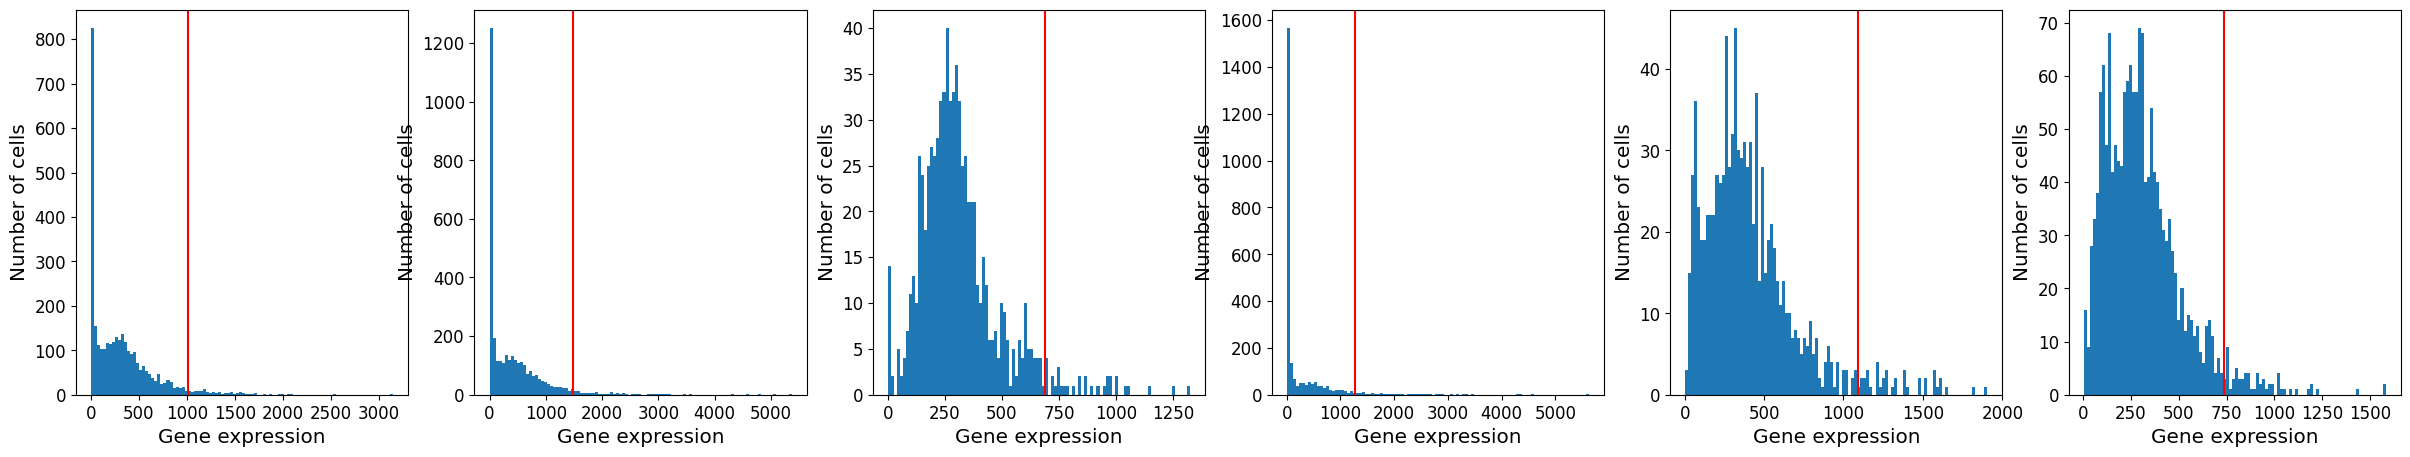

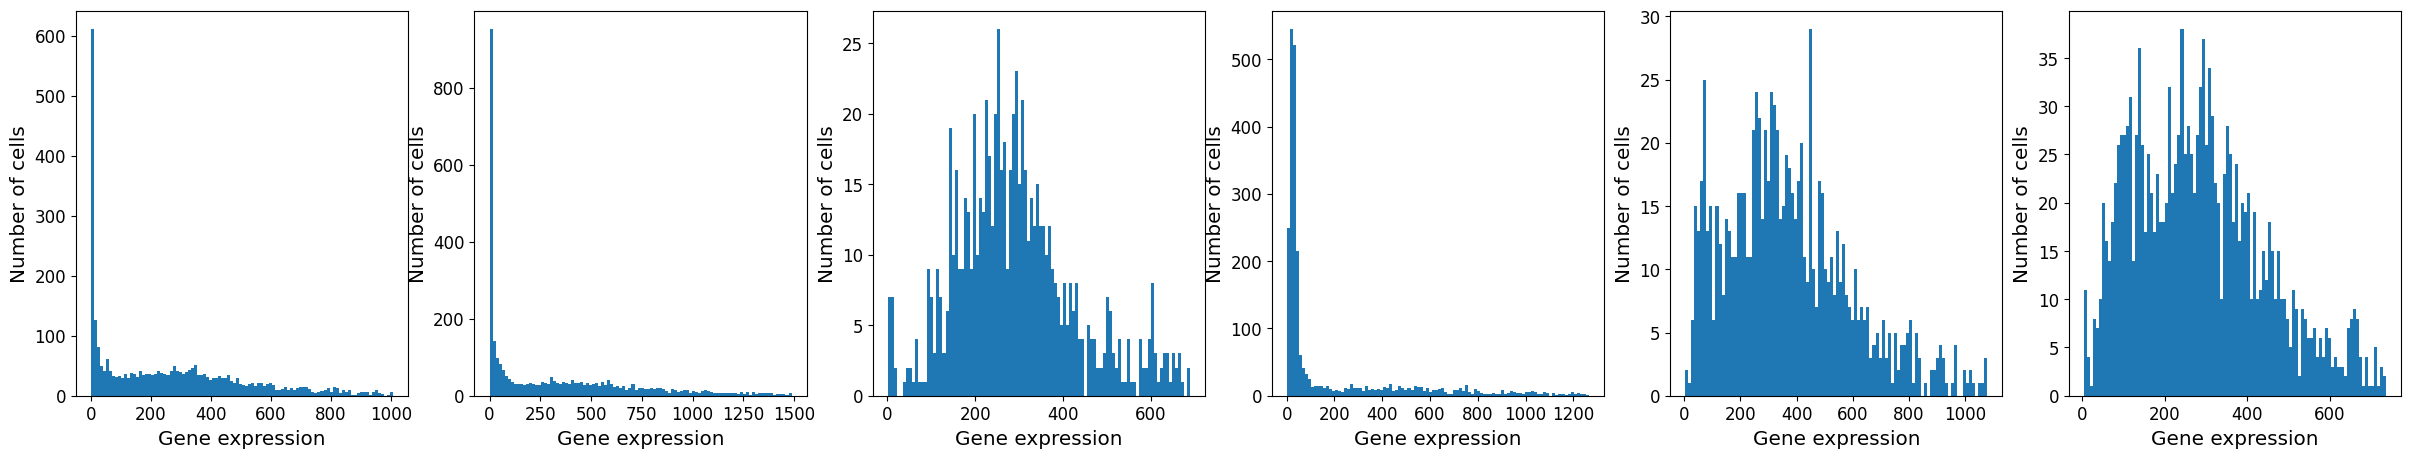

In [8]:
mt_genes = list(set.intersection(*[set(s) for s in [[g for g in dat.columns if g.startswith('MT-')] for dat in data_list_filt.values()]]))

_, axes = plt.subplots(1, len(data_list_filt), figsize=(5 * len(data_list_filt), 5))
for (s, dat), ax in zip(data_list_filt.items(), axes):
    scprep.plot.plot_gene_set_expression(dat, genes=mt_genes, percentile=96, ax=ax)

for s, dat in data_list_filt.items():
    print(f"before mito filt{s}: {dat.shape}")
    dat = scprep.filter.filter_gene_set_expression(data=dat, genes=mt_genes, percentile=96, keep_cells="below")
    print(f"after mito filt {s}: {dat.shape}")
    data_list_filt[s] = dat
    
_, axes = plt.subplots(1, len(data_list_filt), figsize=(5 * len(data_list_filt), 5))
for (s, dat), ax in zip(data_list_filt.items(), axes):
    scprep.plot.plot_gene_set_expression(dat, genes=mt_genes, ax=ax)

In [9]:
# read paper's meta
import pandas as pd
from anndata import AnnData
adata_list = []
for s, dat in data_list_filt.items():
    adata = AnnData(dat)
    adata.obs["sample_labels"] = s
    adata.obs["barcode"] = adata.obs.index
    adata.obs["Time and replicate"] = s.split("_")[-2] + " Gastruloid Rep " + s.split("_")[-1]
    adata.obs["stage"] = s.split("_")[-2]
    rep_id = [s[-1] for s in adata.obs["sample_labels"].str.split("_")]
    adata.obs.index = pd.Index(adata.obs.index.str.cat(adata.obs["sample_labels"], sep='_'))
    adata_list.append(adata)
adata = sc.concat(adata_list)
# merge meta
meta = pd.read_csv(data_path / "GSE169074_gastruloid.all.time.metadata.csv.gz")
meta["barcode"] = [s[0] for s in meta["Cell ID"].str.split("_")]
meta = adata.obs.merge(meta, how="left", on=["barcode", "Time and replicate"])
meta.index = adata.obs.index
adata.obs = meta
mic.io.upload_minn_adata(adata, processing_stage="qc")

Saving AnnData to /tmp/tmpl9jn11vh/minn_gastruloid_0-24h_qc_20260211.h5ad
Uploading to s3://stan-sequencing-data/processed-active/Minn-micropattern-0-24h/minn_gastruloid_0-24h_qc_20260211.h5ad


100%|██████████| 1/1 [00:18<00:00, 18.39s/it]

Upload complete: s3://stan-sequencing-data/processed-active/Minn-micropattern-0-24h/minn_gastruloid_0-24h_qc_20260211.h5ad


In [11]:
adata

AnnData object with n_obs × n_vars = 11844 × 13035
    obs: 'sample_labels', 'barcode', 'Time and replicate', 'stage', 'Cell ID', 'Cell type'

# Integration

In [10]:
mic.io.fetch_minn(cwd, type="adata", stage="qc")

100%|██████████| 1/1 [02:37<00:00, 157.94s/it]


In [11]:
mic.io.fetch_heemskerk(cwd)

100%|██████████| 1/1 [08:55<00:00, 535.74s/it]


100%|██████████| 1/1 [00:01<00:00,  1.23s/it]


In [14]:
adata_minn = mic.io.MINN_ADATA_LIST["qc"]
adata_heemskerk = mic.io.HEEMSKERK_ADATA["adata"]
meta_heemskerk = mic.io.HEEMSKERK_ADATA["meta"]
minn_data_path = cwd / "minn_data"
heemskerk_data_path = cwd / "heemskerk_data"
adata_minn = sc.read_h5ad(minn_data_path / adata_minn)
adata_heemskerk = sc.read_h5ad(heemskerk_data_path / adata_heemskerk)
meta_heemskerk = pd.read_csv(heemskerk_data_path / meta_heemskerk, index_col=0)
adata_heemskerk.obs = meta_heemskerk.loc[adata_heemskerk.obs.index]
print(adata_minn)
print(adata_heemskerk)
print(f"{len(set.intersection(set(adata_heemskerk.var_names), set(adata_minn.var_names)))} genes in common")
adata_heemskerk.obs["source"] = "heemskerk"
adata_minn.obs["source"] = "minn"
adata = sc.concat([adata_heemskerk, adata_minn])
print(adata)
adata.obs = pd.concat([adata_heemskerk.obs, adata_minn.obs])

AnnData object with n_obs × n_vars = 11844 × 13035
    obs: 'sample_labels', 'barcode', 'Time and replicate', 'stage', 'Cell ID', 'Cell type'
AnnData object with n_obs × n_vars = 62402 × 16519
    obs: 'sample_labels', 'leiden_sub', 'leiden_sub_sub2', 'branch_joint', 'dpt_pseudotime', 'leiden_sub_colors', 'leiden_sub_sub2_colors', 'umap_old_48-96h_x', 'umap_old_48-96h_y', 'umap_new_D4-10_x', 'umap_new_D4-10_y'
11434 genes in common
AnnData object with n_obs × n_vars = 74246 × 11434
    obs: 'sample_labels', 'source'


In [15]:
cc_genes = mic.io.read_cc_list(cwd)

100%|██████████| 1/1 [00:00<00:00,  8.10it/s]


In [16]:
mic.utils.normalize_and_select_hvg(adata, n_top_genes=2000)

2026-02-13 03:02:04.268 | INFO     | micropattern.utils:normalize_and_select_hvg:57 - Copying X to counts layer before normalization
2026-02-13 03:02:05.691 | INFO     | micropattern.utils:normalize_and_select_hvg:61 - Normalizing to target sum 10000.0 and applying log1p transformation
2026-02-13 03:02:12.622 | INFO     | micropattern.utils:normalize_and_select_hvg:83 - Saving X to raw before computing HVG
2026-02-13 03:02:12.624 | INFO     | micropattern.utils:normalize_and_select_hvg:87 - Computing top 2000 highly variable genes (seurat_v3)


In [17]:
cc_genes_all = [g for gl in cc_genes.values() for g in gl]
cc_genes_all =  [g for g in adata.var_names if g.split()[0] in cc_genes_all and g not in adata.obs.columns]
print(f"Insert {len(cc_genes_all)} cc genes into obs")
adata.obs = pd.concat([adata.obs, adata[:, cc_genes_all].to_df()], axis=1)

Insert 121 cc genes into obs


In [18]:
mic.integration.integration(
    adata,
    run_name="minn_heemskerk_micropatern_0-10d",
    categorical_covariates_keys=["source"],
    continuous_covariates_keys=cc_genes_all,
    n_latent=80
)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/torch/__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_preci

Training:   0%|          | 0/400 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=400` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=400` reached.


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        
Creating tarball 20260213_SCVI_minn_heemskerk_micropatern_0-10d.tar.gz
Uploading to s3://stan-sequencing-data/processed-active/models/20260213_SCVI_minn_heemskerk_micropatern_0-10d.tar.gz


100%|██████████| 1/1 [00:06<00:00,  6.22s/it]

Upload complete: s3://stan-sequencing-data/processed-active/models/20260213_SCVI_minn_heemskerk_micropatern_0-10d.tar.gz


In [23]:
import umap
sc.pp.neighbors(adata, n_neighbors=50, use_rep="X_scvi", random_state=0)
sc.tl.umap(adata, min_dist=0.01)

In [43]:
trans = umap.UMAP(n_neighbors=50, min_dist=0.01, spread=1.0, n_components=2, negative_sample_rate=5, random_state=1, a=None, b=None).fit(adata.obsm["X_scvi"][~adata.obs["sample_labels"].str.contains("GSM")])
adata.obsm['X_all2heemskerk'] = trans.transform(adata.obsm['X_scvi'])

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [21]:
sc.set_figure_params(figsize=(5,5))

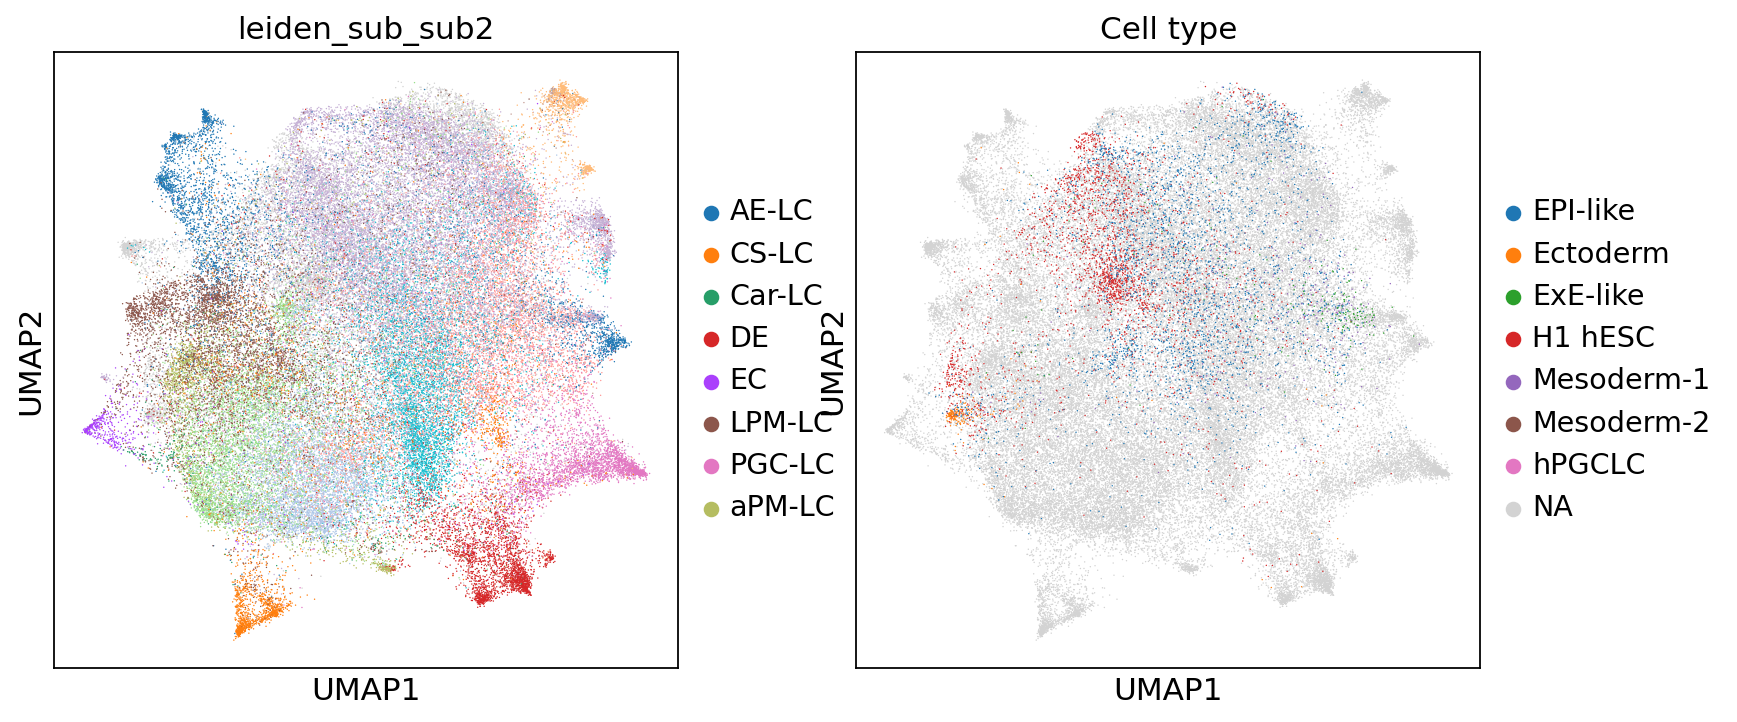

In [24]:
sc.pl.umap(adata, color=["leiden_sub_sub2", "Cell type"])

In [25]:
ax = sc.pl.embedding(adata, basis="X_all2heemskerk", show=False)
sc.pl.embedding(
    adata[adata.obs["sample_labels"].str.contains("GSM")],
    basis="X_all2heemskerk",
    color="Cell type",
    ax=ax,
    size=10
)

KeyError: "Could not find 'X_all2heemskerk' or 'X_X_all2heemskerk' in .obsm"